<a href="https://colab.research.google.com/github/fahadelahikhan/Spring-Mass-Damper-PINN/blob/main/Spring_Mass_Damper_PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Cell 1: Setup, tensors, autograd**

In [1]:
import torch, numpy as np, matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

# TENSOR = NumPy array that can live on a GPU and remember how it was computed.
t = torch.tensor([0.0, 1.0, 2.0, 3.0], requires_grad=True)
# requires_grad=True means "track every operation on me so I can differentiate later".

# AUTOGRAD demo: y = t^2, so dy/dt should be 2t
y = t**2
dy_dt = torch.autograd.grad(
    outputs=y, inputs=t,
    grad_outputs=torch.ones_like(y),  # y is a vector; this says "sum all outputs"
    create_graph=True                 # keep the graph, so we can differentiate AGAIN (for x'')
)[0]
print("dy/dt  =", dy_dt)              # expect [0, 2, 4, 6]

d2y_dt2 = torch.autograd.grad(dy_dt, t, torch.ones_like(dy_dt))[0]
print("d2y/dt2 =", d2y_dt2)           # expect [2, 2, 2, 2]

Using: cuda
dy/dt  = tensor([0., 2., 4., 6.], grad_fn=<MulBackward0>)
d2y/dt2 = tensor([2., 2., 2., 2.])


**Cell 2: Analytical solution ("ground truth")**

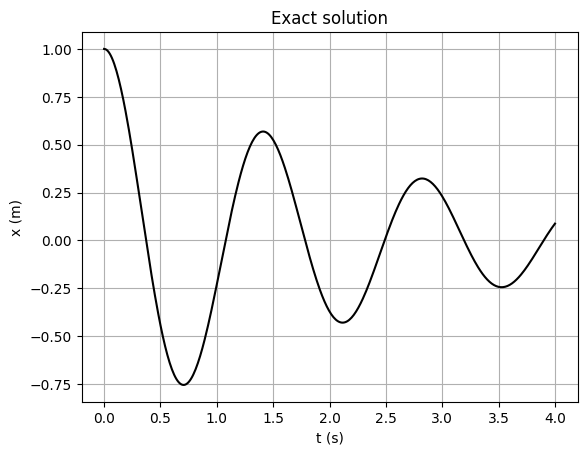

In [2]:
m, c, k = 1.0, 0.8, 20.0
alpha = c / (2*m)
wd = np.sqrt(k/m - alpha**2)

def exact(t):
    return np.exp(-alpha*t) * (np.cos(wd*t) + (alpha/wd)*np.sin(wd*t))

t_np = np.linspace(0, 4, 400)
plt.plot(t_np, exact(t_np), 'k'); plt.xlabel("t (s)"); plt.ylabel("x (m)")
plt.title("Exact solution"); plt.grid(); plt.show()

**Cell 3: The network with nn.Module**

In [3]:
import torch.nn as nn

class PINN(nn.Module):
    def __init__(self, hidden=32, layers=3):
        super().__init__()
        # Build: 1 input (t) -> [hidden neurons + tanh] x layers -> 1 output (x)
        dims = [1] + [hidden]*layers + [1]
        mods = []
        for i in range(len(dims)-1):
            mods.append(nn.Linear(dims[i], dims[i+1]))   # y = W·x + b
            if i < len(dims)-2:
                mods.append(nn.Tanh())                    # smooth activation
        self.net = nn.Sequential(*mods)

    def forward(self, t):
        return self.net(t)   # called automatically when you write model(t)

model = PINN().to(device)
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters()))

# Test: feed 5 times, shape must be (N, 1) = N rows, 1 column
t_test = torch.linspace(0, 4, 5).reshape(-1, 1).to(device)
print(model(t_test))

PINN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Trainable parameters: 2209
tensor([[0.0308],
        [0.0587],
        [0.0640],
        [0.0726],
        [0.0796]], device='cuda:0', grad_fn=<AddmmBackward0>)


**Cell 4: The physics loss**

In [4]:
def derivs(model, t):
    """Return x, x', x'' of the network output w.r.t. time t (via autograd)."""
    x  = model(t)
    dx = torch.autograd.grad(x,  t, torch.ones_like(x),  create_graph=True)[0]
    d2x = torch.autograd.grad(dx, t, torch.ones_like(dx), create_graph=True)[0]
    return x, dx, d2x

def pinn_loss(model, t_col):
    # 1) Physics loss: ODE residual at collocation points
    x, dx, d2x = derivs(model, t_col)
    residual = m*d2x + c*dx + k*x            # should be 0 everywhere
    L_phys = (residual**2).mean()

    # 2) Initial-condition loss at t = 0
    t0 = torch.zeros(1, 1, device=device, requires_grad=True)
    x0, dx0, _ = derivs(model, t0)
    L_ic = ((x0 - 1.0)**2 + (dx0 - 0.0)**2).squeeze()

    return L_phys + L_ic, L_phys, L_ic

# Collocation points: random times in [0, 4] where we demand the ODE holds
t_col = (4.0 * torch.rand(200, 1, device=device)).requires_grad_(True)

total, Lp, Lic = pinn_loss(model, t_col)
print(f"total={total.item():.4f}  physics={Lp.item():.4f}  IC={Lic.item():.4f}")

total=2.5926  physics=1.6508  IC=0.9418


/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


**Cell 5: Training loop with Adam**

In [5]:
torch.manual_seed(0)                      # reproducibility
model = PINN().to(device)                 # fresh network
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# Optimizer = the calibration algorithm. Adam is gradient descent with adaptive step sizes.

history = []
for epoch in range(5001):
    t_col = (4.0 * torch.rand(200, 1, device=device)).requires_grad_(True)  # fresh random points each step

    optimizer.zero_grad()                 # 1) clear old gradients (PyTorch accumulates them)
    loss, Lp, Lic = pinn_loss(model, t_col)
    loss.backward()                       # 2) backprop: d(loss)/d(every weight)
    optimizer.step()                      # 3) nudge weights downhill

    history.append([loss.item(), Lp.item(), Lic.item()])
    if epoch % 500 == 0:
        print(f"epoch {epoch:5d}  total={loss.item():.5f}  phys={Lp.item():.5f}  IC={Lic.item():.5f}")

epoch     0  total=16.51213  phys=15.14844  IC=1.36369
epoch   500  total=0.95561  phys=0.02770  IC=0.92791
epoch  1000  total=0.94113  phys=0.02676  IC=0.91437
epoch  1500  total=0.89773  phys=0.04268  IC=0.85505
epoch  2000  total=0.80228  phys=0.14653  IC=0.65574
epoch  2500  total=0.74138  phys=0.20370  IC=0.53768
epoch  3000  total=0.68391  phys=0.15517  IC=0.52873
epoch  3500  total=0.74056  phys=0.25155  IC=0.48900
epoch  4000  total=0.67649  phys=0.22427  IC=0.45222
epoch  4500  total=0.56902  phys=0.19878  IC=0.37024
epoch  5000  total=0.55674  phys=0.24096  IC=0.31577


**Cell 5b: Retrain with IC weighting (and a quick check plot)**

epoch     0  phys=15.14844  IC=1.363688
epoch  1000  phys=2.61657  IC=0.000685
epoch  2000  phys=1.48999  IC=0.001736
epoch  3000  phys=1.18462  IC=0.000165
epoch  4000  phys=1.12113  IC=0.000198
epoch  5000  phys=1.03101  IC=0.000223
epoch  6000  phys=1.12657  IC=0.000112
epoch  7000  phys=0.92919  IC=0.000112
epoch  8000  phys=1.03497  IC=0.000211
epoch  9000  phys=1.00788  IC=0.000232


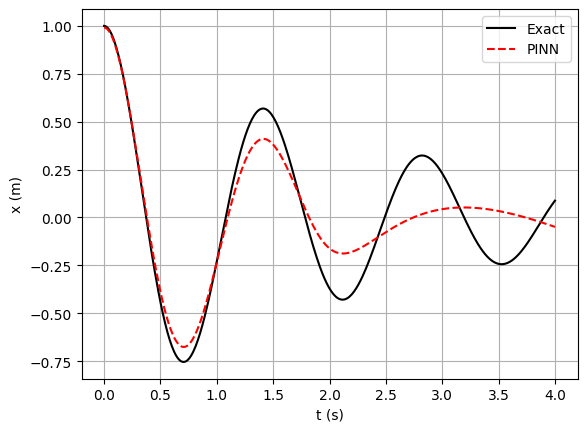

Max abs error: 0.30947573095599595


In [6]:
torch.manual_seed(0)
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3000, gamma=0.3)  # cut lr x0.3 every 3000 steps
w_ic = 100.0                                   # IC weight

history = []
for epoch in range(9001):
    t_col = (4.0 * torch.rand(200, 1, device=device)).requires_grad_(True)
    optimizer.zero_grad()
    _, Lp, Lic = pinn_loss(model, t_col)
    loss = Lp + w_ic * Lic                     # weighted total
    loss.backward()
    optimizer.step(); scheduler.step()
    history.append([loss.item(), Lp.item(), Lic.item()])
    if epoch % 1000 == 0:
        print(f"epoch {epoch:5d}  phys={Lp.item():.5f}  IC={Lic.item():.6f}")

# Quick check against exact solution
t_plot = torch.linspace(0, 4, 400).reshape(-1, 1).to(device)
with torch.no_grad():                          # no_grad: skip gradient tracking when only predicting
    x_pred = model(t_plot).cpu().numpy().ravel()
plt.plot(t_np, exact(t_np), 'k', label="Exact")
plt.plot(t_np, x_pred, 'r--', label="PINN")
plt.xlabel("t (s)"); plt.ylabel("x (m)"); plt.legend(); plt.grid(); plt.show()
print("Max abs error:", np.abs(x_pred - exact(t_np)).max())

**Cell 5c: Better training (Adam, then L-BFGS)**

Adam     0  phys=3.29e-03  IC=9.38e-01
Adam  2000  phys=5.36e-03  IC=3.56e-04
Adam  4000  phys=3.94e-03  IC=8.27e-05
Adam  6000  phys=2.47e-03  IC=4.18e-05
Adam  8000  phys=1.76e-03  IC=8.99e-06
Adam 10000  phys=1.45e-03  IC=2.47e-07


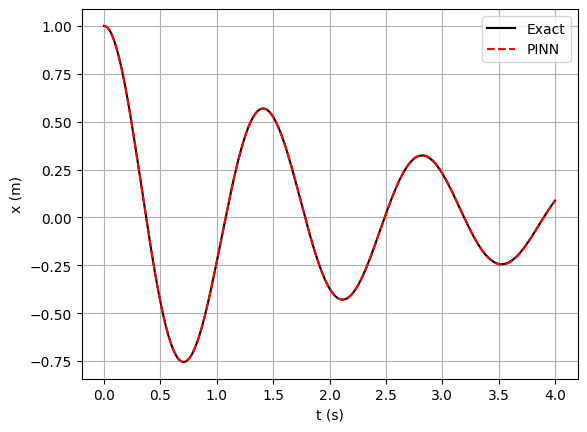

Max abs error: 0.0023564340518018034


In [7]:
def pinn_loss_n(model, t_col, w_ic=1.0):
    x, dx, d2x = derivs(model, t_col)
    Lp = (((m*d2x + c*dx + k*x) / k)**2).mean()      # residual normalized by k
    t0 = torch.zeros(1, 1, device=device, requires_grad=True)
    x0, dx0, _ = derivs(model, t0)
    Lic = ((x0 - 1.0)**2 + dx0**2).squeeze()
    return Lp + w_ic*Lic, Lp, Lic

torch.manual_seed(0)
model = PINN(hidden=48).to(device)                    # slightly wider network
opt = torch.optim.Adam(model.parameters(), lr=3e-3)
sched = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9997)  # smooth decay

# --- Stage 1: Adam with fresh random points ---
history = []
for epoch in range(10001):
    t_col = (4.0*torch.rand(300, 1, device=device)).requires_grad_(True)
    opt.zero_grad()
    loss, Lp, Lic = pinn_loss_n(model, t_col)
    loss.backward(); opt.step(); sched.step()
    history.append([loss.item(), Lp.item(), Lic.item()])
    if epoch % 2000 == 0:
        print(f"Adam {epoch:5d}  phys={Lp.item():.2e}  IC={Lic.item():.2e}")

# --- Stage 2: L-BFGS on a FIXED grid (it needs a deterministic loss) ---
t_fix = torch.linspace(0, 4, 400, device=device).reshape(-1, 1).requires_grad_(True)
lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=500,
                          history_size=50, line_search_fn="strong_wolfe")
def closure():                                        # L-BFGS re-evaluates the loss several times per step
    lbfgs.zero_grad()
    loss, _, _ = pinn_loss_n(model, t_fix)
    loss.backward()
    return loss
lbfgs.step(closure)

# --- Check ---
t_plot = torch.linspace(0, 4, 400).reshape(-1, 1).to(device)
with torch.no_grad():
    x_pred = model(t_plot).cpu().numpy().ravel()
plt.plot(t_np, exact(t_np), 'k', label="Exact")
plt.plot(t_np, x_pred, 'r--', label="PINN")
plt.xlabel("t (s)"); plt.ylabel("x (m)"); plt.legend(); plt.grid(); plt.show()
print("Max abs error:", np.abs(x_pred - exact(t_np)).max())

**Cell 5d: More L-BFGS rounds (continues the current model)**

round 0: phys=8.49e-07  IC=2.87e-12  max err=0.0004
round 1: phys=8.49e-07  IC=2.87e-12  max err=0.0004
round 2: phys=8.49e-07  IC=2.87e-12  max err=0.0004
round 3: phys=8.49e-07  IC=2.87e-12  max err=0.0004
round 4: phys=8.49e-07  IC=2.87e-12  max err=0.0004


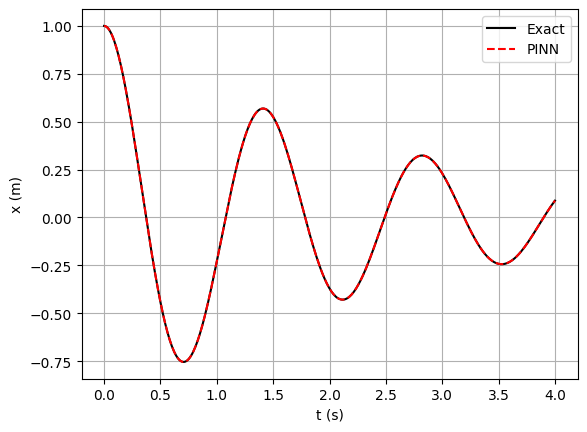

In [8]:
def max_err():
    with torch.no_grad():
        xp = model(t_plot).cpu().numpy().ravel()
    return xp, np.abs(xp - exact(t_np)).max()

for r in range(5):
    lbfgs.step(closure)                       # each call = up to 500 more iterations
    with torch.enable_grad():
        L, Lp_, Lic_ = pinn_loss_n(model, t_fix)
    x_pred, e = max_err()
    print(f"round {r}: phys={Lp_.item():.2e}  IC={Lic_.item():.2e}  max err={e:.4f}")

plt.plot(t_np, exact(t_np), 'k', label="Exact")
plt.plot(t_np, x_pred, 'r--', label="PINN")
plt.xlabel("t (s)"); plt.ylabel("x (m)"); plt.legend(); plt.grid(); plt.show()

**Cell 6: Validation figures (README-ready)**

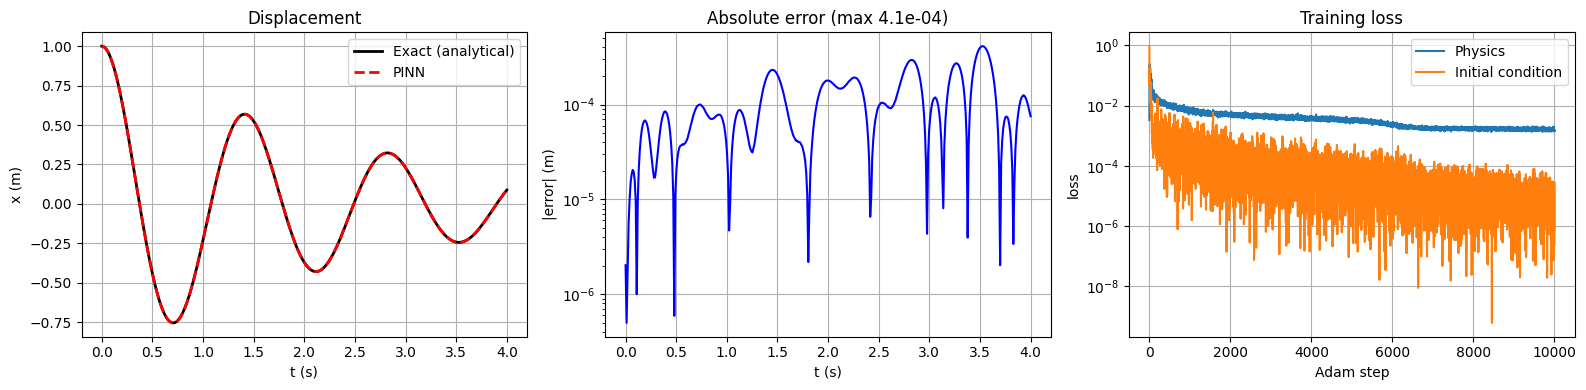

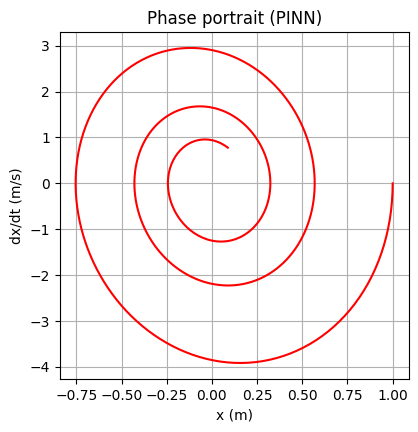

In [9]:
import os
os.makedirs("results", exist_ok=True)
x_pred, e = max_err()
x_ex = exact(t_np)
H = np.array(history)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

# (a) Solution comparison
ax[0].plot(t_np, x_ex, 'k', lw=2, label="Exact (analytical)")
ax[0].plot(t_np, x_pred, 'r--', lw=2, label="PINN")
ax[0].set(xlabel="t (s)", ylabel="x (m)", title="Displacement"); ax[0].legend(); ax[0].grid()

# (b) Pointwise error
ax[1].semilogy(t_np, np.abs(x_pred - x_ex) + 1e-12, 'b')
ax[1].set(xlabel="t (s)", ylabel="|error| (m)", title=f"Absolute error (max {e:.1e})"); ax[1].grid()

# (c) Adam loss history
ax[2].semilogy(H[:, 1], label="Physics"); ax[2].semilogy(H[:, 2], label="Initial condition")
ax[2].set(xlabel="Adam step", ylabel="loss", title="Training loss"); ax[2].legend(); ax[2].grid()

plt.tight_layout(); plt.savefig("results/p1_validation.png", dpi=150); plt.show()

# Bonus: phase portrait (x vs velocity), a spiral into the origin = energy dissipating
t_g = torch.linspace(0, 4, 400).reshape(-1, 1).to(device).requires_grad_(True)
x_g, v_g, _ = derivs(model, t_g)
plt.figure(figsize=(4.5, 4.5))
plt.plot(x_g.detach().cpu(), v_g.detach().cpu(), 'r')
plt.xlabel("x (m)"); plt.ylabel("dx/dt (m/s)"); plt.title("Phase portrait (PINN)")
plt.grid(); plt.savefig("results/p1_phase.png", dpi=150); plt.show()